In [1]:
using Pkg
Pkg.activate("../")
using Plots

  Activating project at `~/Documents/Workshops/Surrogate/TwoVariableInter/3cpn_phasediag`


In [2]:
using Plots
using DataFrames
# 包含并使用您的 Surrogates 模块
include("../src/Surrogates.jl")
using .Surrogates
# 定义与 Python 脚本相同的测试函数
true_surface(x, y) = sin(pi * x) * cos(pi * y)
true_dzdx(x, y) = pi * cos(pi * x) * cos(pi * y)
true_dzdy(x, y) = -1 * pi * sin(pi * x) * sin(pi * y)

println("模块加载成功！")

模块加载成功！


In [3]:
# 生成 5x5 的格点
x_samples_1d = range(-1, 1, length=5)
y_samples_1d = range(-1, 1, length=5)

x_train = Float64[]
y_train = Float64[]

for x in x_samples_1d, y in y_samples_1d
    push!(x_train, x)
    push!(y_train, y)
end

z_train = true_surface.(x_train, y_train)
dzdx_train = true_dzdx.(x_train, y_train)
dzdy_train = true_dzdy.(x_train, y_train)

coords_train = hcat(x_train, y_train)

println("成功生成 $(length(z_train)) 个训练样本点。")


成功生成 25 个训练样本点。


In [4]:
# 调用您在 Surrogates.jl 中定义的函数
f_linear  = scipy_linear_surrogate(coords_train, z_train)
f_cubic   = scipy_cubic_surrogate(coords_train, z_train)
# f_nearest = scipy_nearest_surrogate(coords_train, z_train)
f_kriging = scipy_kriging_surrogate(coords_train, z_train)
f_chs_py = scipy_chs_surrogate(coords_train, z_train)
f_bchs_jl, grad_bchs_jl = julia_bchs_2d_surrogate(coords_train, z_train, dzdx_train, dzdy_train)
f_idw = scipy_idw_surrogate(coords_train, z_train, p=2)
f_natural_py = scipy_natural_neighbor_surrogate(coords_train, z_train)
f_natural_jl = julia_natural_neighbor_surrogate(coords_train, z_train)  

println("代理模型构建完成")

代理模型构建完成


In [5]:
μs = grad_bchs_jl.(x_grid, y_grid)
μs[:][1]

UndefVarError: UndefVarError: `x_grid` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

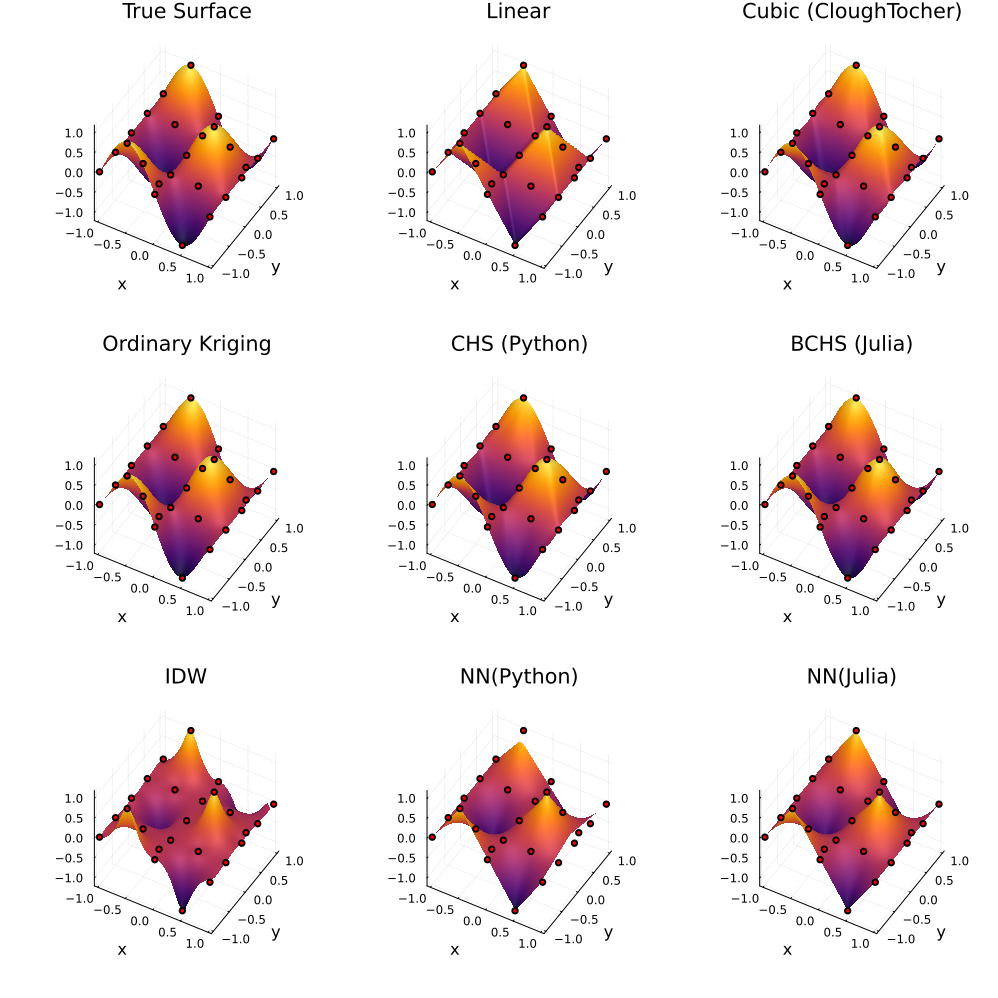

In [6]:
x_grid = range(-1, 1, length=50)
y_grid = range(-1, 1, length=50)
# 封装一个快捷绘图函数，避免重复写 scatter!
function plot_with_samples(f, title_str)
    # 绘制曲面
    p = surface(x_grid, y_grid, (x,y) -> f(x,y); 
                 title=title_str, xlabel="x", ylabel="y", zlim=(-1.2, 1.2), 
                 camera=(30, 45), colorbar=false)
    # 叠加样本点 (红色圆点)
    scatter!(p, x_train, y_train, z_train, marker=(:circle, 3, :red), label=false)
    return p
end
# 生成各个子图
p1 = plot_with_samples(true_surface, "True Surface")
p2 = plot_with_samples(f_linear, "Linear")
p3 = plot_with_samples(f_cubic, "Cubic (CloughTocher)")
# p4 = plot_with_samples(f_nearest, "Nearest")
p4 = plot_with_samples(f_kriging, "Ordinary Kriging")
p5 = plot_with_samples(f_chs_py, "CHS (Python)")
p6 = plot_with_samples(f_bchs_jl, "BCHS (Julia)")
p7 = plot_with_samples(f_idw, "IDW")
p8 = plot_with_samples(f_natural_py, "NN(Python)")
p9 = plot_with_samples(f_natural_jl, "NN(Julia)")

# 综合布局显示
plot(p1, p2, p3, p4, p5, p6, p7, p8, p9, layout=(3,3), size=(1000, 1000))